-*- encoding: utf-8 -*-
This file is part of GaPSE
Copyright (C) 2022 Matteo Foglieni
GaPSE is free software: you can redistribute it and/or modify
it under the terms of the GNU General Public License as published by
the Free Software Foundation, either version 3 of the License, or
(at your option) any later version.
GaPSE is distributed in the hope that it will be useful, but
WITHOUT ANY WARRANTY; without even the implied warranty of
MERCHANTABILITY or FITNESS FOR A PARTICULAR PURPOSE. See the GNU
General Public License for more details.
You should have received a copy of the GNU General Public License
along with GaPSE. If not, see <http://www.gnu.org/licenses/>.

## GaPSE setup

In [1]:

using Pkg
Pkg.activate(@__DIR__)

# This environment is (re)built here, so that a fresh clone - or a different
# Julia version - needs no manual setup step.
#  - GaPSE is NOT a registered package: an environment reaches it only through
#    the `path` entry that `Pkg.develop` writes into `Manifest.toml`. Checking
#    `Base.identify_package` alone is not enough: it resolves the UUID from
#    `Project.toml` and succeeds even when the source cannot be found.
#  - `Project.toml` holds names and UUIDs only, is Julia-version INdependent and
#    is tracked by git; it is rebuilt from `THEORY_DEPS` if it is missing.
#  - `Manifest.toml` holds the resolved versions, IS Julia-version specific and
#    is gitignored; `Pkg.resolve()` + `Pkg.instantiate()` rebuild it for the
#    Julia that is running. `resolve` first, or `instantiate` refuses whenever
#    `Project.toml` declares more than the manifest knows about.
# Nothing is downloaded when the environment is already complete.
let THEORY_DEPS = ["Plots", "PyPlot", "LaTeXStrings", "QuadGK",
                   "DelimitedFiles", "Printf", "SpecialFunctions"]
    declared = collect(keys(Pkg.project().dependencies))
    id = Base.identify_package("GaPSE")
    if !("GaPSE" in declared) || isnothing(id) || isnothing(Base.locate_package(id))
        @info "theory/: making the GaPSE of this repository available"
        Pkg.develop(path=dirname(@__DIR__))
    end
    todo = filter(d -> !(d in declared), THEORY_DEPS)
    isempty(todo) || (@info "theory/: adding the missing dependencies" todo; Pkg.add(todo))
    Pkg.resolve()
    Pkg.instantiate()
end

using GaPSE

using Plots, LaTeXStrings, QuadGK, DelimitedFiles, Printf

# `pyplot()` needs a working matplotlib; `gr()` is used instead where it is absent
try
    pyplot()
catch err
    @warn "theory/: PyPlot cannot be initialised; falling back to the GR backend. " *
          "The figures will look slightly different." exception = err
    gr()
end

  Activating project at `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory`
     Project No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Project.toml`
    Manifest No packages added to or removed from `~/AAA_TESI_MAGISTRALE/GaPSE_CODING/GaPSE-worktree/myspline/theory/Manifest.toml`
Precompiling packages...
   6172.3 ms  ✓ GaPSE
  1 dependency successfully precompiled in 7 seconds. 270 already precompiled.
  33 dependencies precompiled but different versions are currently loaded (ArgTools, Base64, Dates, Downloads, InteractiveUtils, JLFzf, JLLWrappers, JuliaSyntaxHighlighting, LibCURL, LibCURL_jll, LibGit2, LibGit2_jll, LibSSH2_jll, Logging, Markdown, MozillaCACerts_jll, NetworkOptions, OpenSSL_jll, Pkg, Pkg → REPLExt, PrecompileTools, Preferences, Printf, REPL, StyledStrings, TOML, Tar, UUIDs, Unicode, Zlib_jll, fzf_jll, nghttp2_jll and p7zip_jll). Restart julia to access the new versions. Otherwise, 160 dependents

Plots.PyPlotBackend()

In [2]:

const PATH_TO_GAPSE = normpath(joinpath(@__DIR__, ".."))
const FILE_PS = joinpath(PATH_TO_GAPSE, "data", "WideA_ZA_pk.dat")

const DIR = joinpath(@__DIR__, "input_ps")
@assert isdir(DIR) "ERROR: DIR=$DIR DOESN'T EXIST!!!"

const SAVE_TO_DOCS = true
const DOCS_ASSETS = joinpath(PATH_TO_GAPSE, "docs", "src", "assets", "input_ps")

const IPS = GaPSE.InputPS(FILE_PS)

const PS_TABLE = readdlm(FILE_PS, comments=true)
const K_TAB, P_TAB = PS_TABLE[:, 1], PS_TABLE[:, 2]
const K_MIN_TAB, K_MAX_TAB = extrema(K_TAB)

# The two power laws `InputPS` uses outside the tabulated range, P(q) = a + b q^s.
# `l_` is the q -> 0 side, `r_` the q -> +infinity one.
left_powerlaw(q) = IPS.l_a + IPS.l_b * q^IPS.l_si
right_powerlaw(q) = IPS.r_a + IPS.r_b * q^IPS.r_si

# The range over which GaPSE's `IPSTools` actually integrates: `xicalc` is called
# with these, whatever `k_min`/`k_max` are passed for the stored sigma_i.
const KS_XICALC = (1e-5, 1e3)

(1.0e-5, 1000.0)

## Plot functions

In [3]:

"""
    plot_kwargs(kwargs...) :: Dict

The defaults every figure of this directory shares, with anything in `kwargs...`
overriding them. `merge` keeps the value of the **last** dictionary for a repeated
key, so whatever is passed in always wins:

```julia
plot_kwargs()                       # the defaults
plot_kwargs(:dpi => 150)            # the defaults, with dpi = 150
plot_kwargs(:whatever => 3)         # unknown keys are passed through to Plots
```
"""
function plot_kwargs(kwargs...)
    dict_defaults = Dict(
        :size => (1000, 400), :dpi => 300, :legendposition => :outerright,
        :legendfontsize => 11, :guidefontsize => 14, :tickfontsize => 11,
        :titlefontsize => 16, :left_margin => 10Plots.mm, :bottom_margin => 6Plots.mm,
        # a y label that reads horizontally: see `hlabel` for the padding it needs
        :yguidefontrotation => -90,
    )
    # in `merge`, if a key is repeated the LAST collection has priority
    merge(dict_defaults, Dict(kwargs))
end

"""
    logticks(lo, hi; step=1) :: Vector{Float64}
    logticks(xs; step=1) :: Vector{Float64}

Decade ticks covering `[lo, hi]`, one every `step` decades. The second form reads the
range off the extrema of `xs`, which is handy when the ticks should simply follow the
data:

```julia
logticks(1e-7, 1e4; step=2)     # 1e-7, 1e-5, ..., 1e3
logticks(qs)                    # one tick per decade spanned by qs
```
"""
logticks(lo, hi; step=1) = 10.0 .^ (floor(Int, log10(lo)):step:ceil(Int, log10(hi)))
logticks(xs; step=1) = logticks(extrema(xs)...; step=step)

"""
    hlabel(s; pad=10) :: String

A y-axis label meant to be read horizontally, i.e. together with
`yguidefontrotation = -90` (which `plot_kwargs` sets by default).

`Plots` places the y guide at a fixed offset from the axis, measured as if the label
were vertical. Once it is rotated flat it therefore lands on top of the tick labels,
and there is no portable option to move it: padding it with trailing spaces is the
only thing that works across backends. Keeping that workaround inside one function means
only `pad` has to be tuned per figure, and a better mechanism - should `Plots` ever
grow one - has to be applied in a single place.
"""
hlabel(s; pad=10) = s * " "^pad

"""
    vspec(r, l; ls=:dash, lw=2, c=:black, alpha=0.55, fmt=:sci1) :: NamedTuple

One entry for `vlines!`: a pair of vertical lines at `r = (lo, hi)`, labelled `l`,
drawn with the given style. `fmt` is `:sci1` for `1.0e-06` or `:sci0` for `1e-06`.
Passing `r = nothing` makes `vlines!` skip it, which is how a figure drops one of the
markers without having to rebuild the whole list.
"""
vspec(r, l; ls=:dash, lw=2, c=:black, alpha=0.55, fmt=:sci1) =
    (r=r, l=l, ls=ls, lw=lw, c=c, alpha=alpha, fmt=fmt)

"""
    vlines!(p, specs) :: Plots.Plot

Draw every `vspec` of `specs` on `p`.

This takes the place of the earlier `r1/l1/ls1/lw1/c1/alpha1`, `r2/...`, `r3/...`
keyword triplets: eighteen keywords that only ever described three lines, could not
describe a fourth, and had to be forwarded by hand through every plotting function.
A figure now carries a single `specs` keyword, overriding one entry is
`vspec(KS_DATA, "input file"; c=:green)`, and adding a fourth marker is one more
element of the vector.
"""
function vlines!(p, specs)
    for v in specs
        isnothing(v.r) && continue
        lab = v.fmt === :sci0 ? @sprintf("%s: [%.0e, %.0e]", v.l, v.r...) :
              @sprintf("%s: [%.1e, %.1e]", v.l, v.r...)
        vline!(p, [v.r...]; ls=v.ls, lw=v.lw, c=v.c, alpha=v.alpha, label=lab)
    end
    p
end

# The vertical markers this page uses. A figure overrides one entry with e.g.
# `vspec((K_MIN_TAB, K_MAX_TAB), "data"; c=:green)`, drops it with `r = nothing`,
# or adds a fourth simply by appending to the vector it is given.
VSPECS_PS() = [
    vspec((K_MIN_TAB, K_MAX_TAB), "tabulated range"; c=:gray, alpha=0.6, ls=:solid),
]

"""
    plot_input_ps(; qs, xscale, yscale, xlabel, ylabel, title, specs,
                    xticksmin, xticksmax, xticksstep, kwargs...) :: Plots.Plot

``P(q)`` over many decades, with the two asymptotic power laws drawn through it and
the tabulated range marked. Outside that range the curve *is* the power law: the
dashed lines and the solid one lie on top of each other there, which is the point of
the figure.

Every label, scale, tick range and marker is a keyword, and anything not listed is
handed on to `plot_kwargs`, so a one-off variant needs no editing of this function:

```julia
plot_input_ps(; title = "", specs = [], size = (1400, 600))
```
"""
function plot_input_ps(;
    qs=10 .^ range(-8, 4, length=2000),
    xscale=:log10, yscale=:log10,
    xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]",
    ylabel=hlabel(L"P(q)"; pad=2),
    title="The input matter Power Spectrum",
    specs=VSPECS_PS(),
    xticksmin=1e-8, xticksmax=1e4, xticksstep=2,
    yticksmin=1e-10, yticksmax=1e8, yticksstep=2,
    left_margin=16Plots.mm,
    kwargs...
)
    p = plot(; xscale=xscale, yscale=yscale, xlabel=xlabel, ylabel=ylabel,
        title=title, plot_kwargs(:left_margin => left_margin, kwargs...)...)

    plot!(p, qs, [IPS(q) for q in qs], lw=2.5, c=:black, label="InputPS")
    # NOT `scatter!`: with the PyPlot backend that routes to `plt.scatter`, which warns
    # "No data for colormapping provided via 'c'" when the colour is a single value.
    # A `plot!` series with `lw=0` and a marker shape goes to `plt.plot` instead.
    plot!(p, K_TAB, P_TAB, lw=0, markershape=:circle, ms=1.6, mc=:orange, msw=0,
        label="tabulated data")

    ls = 10 .^ range(-8, log10(K_MIN_TAB) + 1.5, length=200)
    rs = 10 .^ range(log10(K_MAX_TAB) - 1.5, 4, length=200)
    plot!(p, ls, left_powerlaw.(ls), lw=2, ls=:dash, c=:red,
        label=@sprintf("left: P ~ q^{%+.3f}", IPS.l_si))
    plot!(p, rs, right_powerlaw.(rs), lw=2, ls=:dash, c=:blue,
        label=@sprintf("right: P ~ q^{%+.3f}", IPS.r_si))

    vlines!(p, specs)
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    isnothing(yticksmin) || yticks!(p, logticks(yticksmin, yticksmax; step=yticksstep))
    p
end

"""
    plot_local_slope(; qs, xscale, yscale, xlabel, ylabel, title, specs,
                       show_cdm_tail, xticksmin, xticksmax, xticksstep,
                       left_margin, kwargs...) :: Plots.Plot

The local logarithmic slope ``\\mathrm{d}\\ln P / \\mathrm{d}\\ln q``. It is what decides
the convergence of each ``\\sigma_i``: the integrand of ``\\sigma_i`` goes as
``q^{\\,2-i+\\mathrm{d}\\ln P/\\mathrm{d}\\ln q}``, so the moment converges at the UV end
when that exponent is below ``-1``, and at the IR end when it is above.

The y axis is linear here, so it keeps the default ticks instead of `logticks`.
"""
function plot_local_slope(;
    qs=10 .^ range(-8, 4, length=2000),
    xscale=:log10, yscale=:identity,
    xlabel=L"q \; [h \, \mathrm{Mpc}^{-1}]",
    ylabel=hlabel(L"\frac{\mathrm{d}\ln P}{\mathrm{d}\ln q}"; pad=6),
    title="Local slope of the input Power Spectrum",
    specs=VSPECS_PS(),
    show_cdm_tail=true,
    xticksmin=1e-8, xticksmax=1e4, xticksstep=2,
    left_margin=32Plots.mm,
    kwargs...
)
    sl = [(log(IPS(q * 1.01)) - log(IPS(q / 1.01))) / (2 * log(1.01)) for q in qs]
    p = plot(; xscale=xscale, yscale=yscale, xlabel=xlabel, ylabel=ylabel,
        title=title, plot_kwargs(:left_margin => left_margin, kwargs...)...)
    plot!(p, qs, sl, lw=2.5, c=:black, label="InputPS")
    hline!(p, [IPS.l_si], ls=:dash, lw=2, c=:red,
        label=@sprintf("left fit: %+.3f", IPS.l_si))
    hline!(p, [IPS.r_si], ls=:dash, lw=2, c=:blue,
        label=@sprintf("right fit: %+.3f", IPS.r_si))
    show_cdm_tail && hline!(p, [-3.0], ls=:dot, lw=2, c=:green,
        label=L"-3 \;:\; \mathrm{the \; CDM \; tail}")
    vlines!(p, specs)
    xticks!(p, logticks(xticksmin, xticksmax; step=xticksstep))
    p
end

plot_local_slope

## Table functions

In [4]:

"""
    convergence_of_the_sigmas(; io)

For each ``\\sigma_i``, the exponent of its integrand at the two ends and the
verdict. The integrand of ``\\sigma_i`` is ``q^{2-i} P(q)``, so with
``P \\sim q^{s}`` it behaves as ``q^{2-i+s}``: the integral converges at ``q \\to 0``
when ``2-i+s > -1`` and at ``q \\to \\infty`` when ``2-i+s < -1``.
"""
function convergence_of_the_sigmas(; io=stdout)
    println(io, "\n### does sigma_i converge?   (integrand q^(2-i) P(q))\n")
    @printf(io, "%-10s%14s%14s%14s%14s\n", "sigma_i",
        "IR exponent", "IR verdict", "UV exponent", "UV verdict")
    for i in 0:4
        eir, euv = 2 - i + IPS.l_si, 2 - i + IPS.r_si
        @printf(io, "%-10s%14.3f%14s%14.3f%14s\n", "sigma_$i",
            eir, eir > -1 ? "converges" : "DIVERGES",
            euv, euv < -1 ? "converges" : "DIVERGES")
    end
    println(io, "\nWith the true CDM tail P ~ k^(n_s-4) ln^2(k) ~ k^-3 the UV exponent of")
    println(io, "sigma_0 would be exactly -1, i.e. sigma_0 would be LOGARITHMICALLY divergent.")
    println(io, "The fitted right slope here is $(round(IPS.r_si, digits=4)), shallower than -3, so in")
    println(io, "GaPSE sigma_0 diverges as a power: sigma_0(<K) ~ K^$(round(3 + IPS.r_si, digits=3)).")
end

"""
    fitted_exponents(; io)

Print the two fitted power laws and the slope measured on the tabulated data.
"""
function fitted_exponents(; io=stdout)
    sl(a, b) = log(P_TAB[b] / P_TAB[a]) / log(K_TAB[b] / K_TAB[a])
    n = length(K_TAB)
    println(io, "\n### the two power laws of InputPS\n")
    @printf(io, "  left : P(q) = %.5e + %.5e * q^%+.5f\n", IPS.l_a, IPS.l_b, IPS.l_si)
    @printf(io, "  right: P(q) = %.5e + %.5e * q^%+.5f\n", IPS.r_a, IPS.r_b, IPS.r_si)
    println(io, "\n### slope measured on the tabulated data\n")
    @printf(io, "  first decade [%.3e, %.3e] : %+.4f\n", K_TAB[1], K_TAB[10], sl(1, 10))
    @printf(io, "  last decade  [%.3e, %.3e] : %+.4f\n", K_TAB[n-10], K_TAB[n], sl(n - 10, n))
end

fitted_exponents

## Saving functions

In [5]:

function save_plot(p, name)
    savefig(p, joinpath(DIR, name))
    SAVE_TO_DOCS && isdir(DOCS_ASSETS) && savefig(p, joinpath(DOCS_ASSETS, name))
    nothing
end

function save_data(; qs=10 .^ range(-8, 4, length=2000))
    open(joinpath(DIR, "input_ps.txt"), "w") do io
        println(io, "# The input matter Power Spectrum as InputPS returns it,")
        println(io, "# together with its two asymptotic power laws.")
        println(io, "# Input file: $(basename(FILE_PS)), tabulated on [$(K_MIN_TAB), $(K_MAX_TAB)]")
        println(io, "# q \t P(q) \t left_powerlaw \t right_powerlaw")
        for q in qs
            println(io, join([q, IPS(q), left_powerlaw(q), right_powerlaw(q)], " \t "))
        end
    end
    open(joinpath(DIR, "input_ps_slopes.txt"), "w") do io
        println(io, "# Asymptotic behaviour of $(basename(FILE_PS)) and its consequences")
        fitted_exponents(io=io)
        convergence_of_the_sigmas(io=io)
    end
    nothing
end

save_data (generic function with 1 method)

## The two power laws

`InputPS` continues the tabulated `P(q)` with a power law on each side. Those two
exponents, not the tabulated data, decide whether a given `σ_i` is a number or is
fixed by wherever the integral is cut.

In [6]:
fitted_exponents()


### the two power laws of InputPS

  left : P(q) = 0.00000e+00 + 3.01231e+06 * q^+0.96000
  right: P(q) = 0.00000e+00 + 9.16011e+01 * q^-2.64113

### slope measured on the tabulated data

  first decade [2.056e-07, 3.112e-07] : +0.9600
  last decade  [1.276e+01, 2.023e+01] : -2.6580


## The spectrum and its asymptotes

Outside the tabulated range the solid curve *is* the dashed power law — that is the
point of the first figure; the second shows the same as a local slope.

Every label, scale, tick range and vertical marker is a keyword, and anything else
goes to `plot_kwargs`, so a variant needs no editing of the function:
`plot_input_ps(; specs=[], size=(1400,600), yticksstep=1)`.

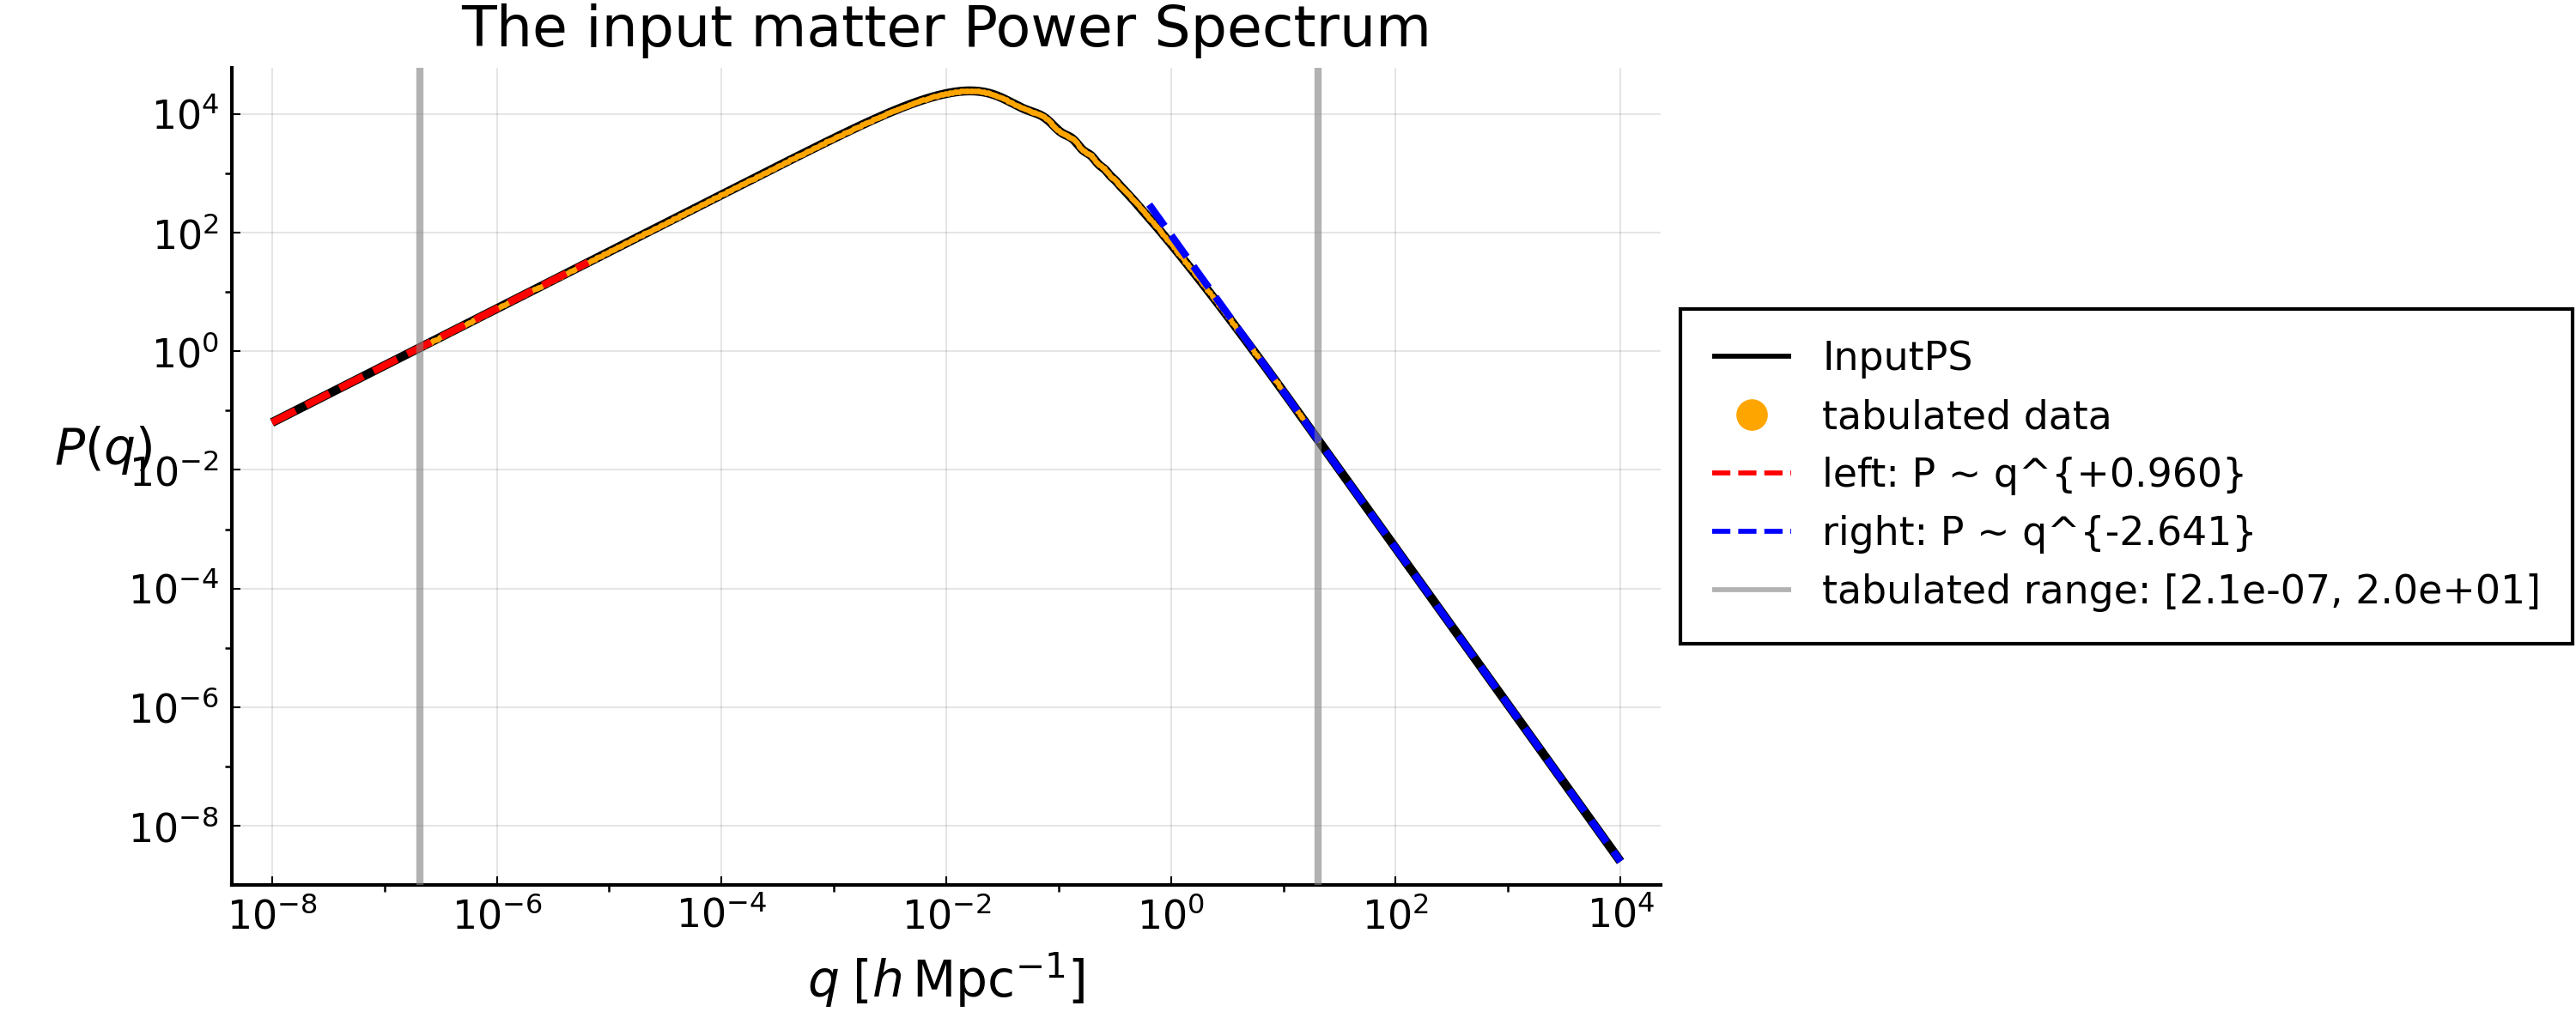

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


In [7]:
plot_input_ps()

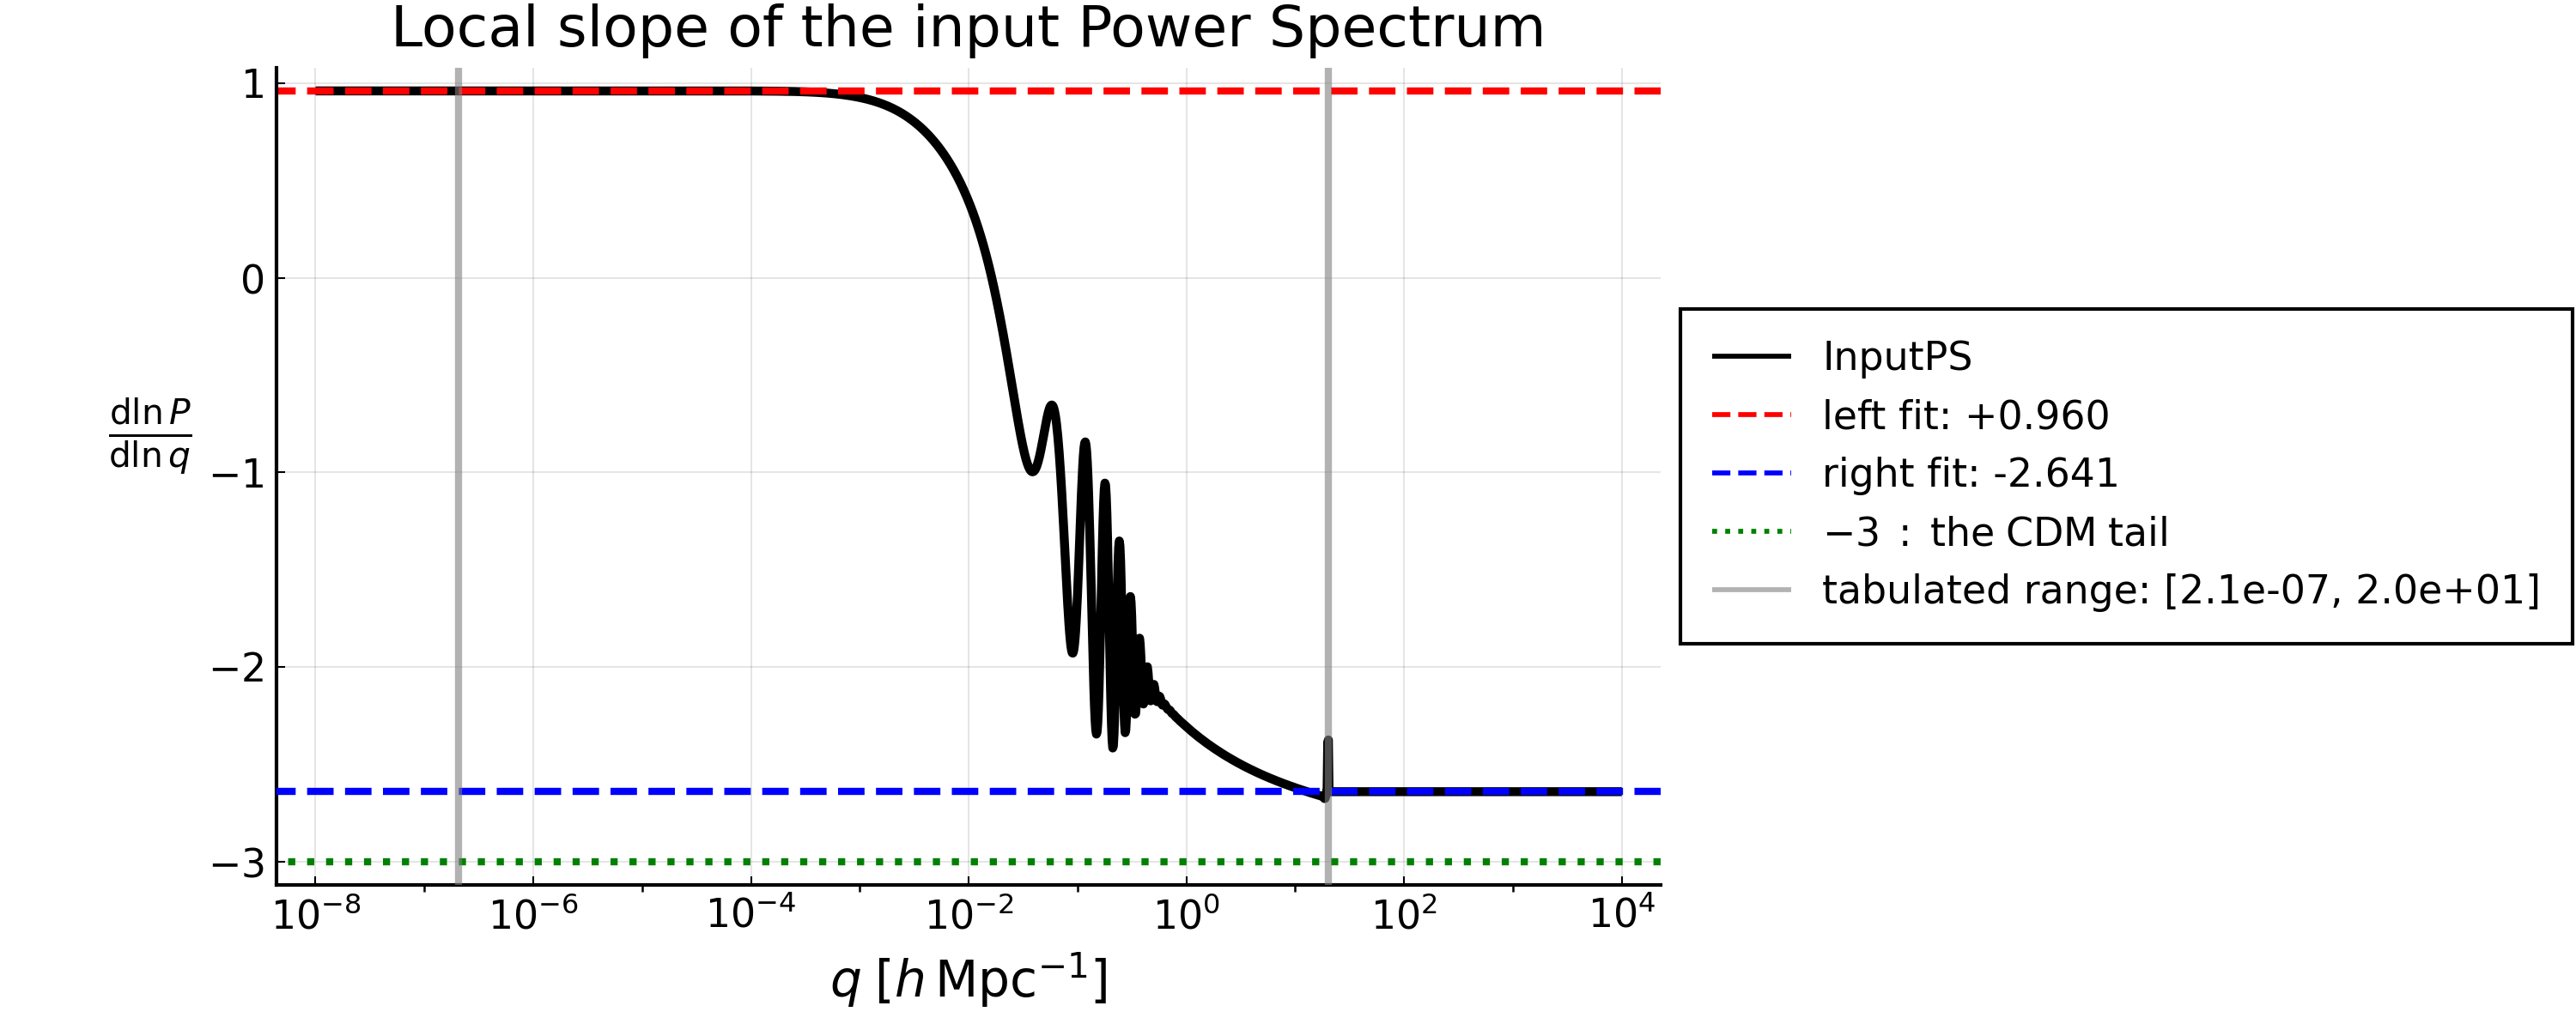

In [8]:
plot_local_slope()

## Which moments converge?

The integrand of `σ_i` is `q^(2-i) P(q)`, so with `P ~ q^s` it goes as `q^(2-i+s)`:
the integral converges at `q → 0` when that exponent is `> -1`, and at `q → ∞` when
it is `< -1`.

In [9]:
convergence_of_the_sigmas()


### does sigma_i converge?   (integrand q^(2-i) P(q))

sigma_i      IR exponent    IR verdict   UV exponent    UV verdict
sigma_0            2.960     converges        -0.641      DIVERGES
sigma_1            1.960     converges        -1.641     converges
sigma_2            0.960     converges        -2.641     converges
sigma_3           -0.040     converges        -3.641     converges
sigma_4           -1.040      DIVERGES        -4.641     converges

With the true CDM tail P ~ k^(n_s-4) ln^2(k) ~ k^-3 the UV exponent of
sigma_0 would be exactly -1, i.e. sigma_0 would be LOGARITHMICALLY divergent.
The fitted right slope here is -2.6411, shallower than -3, so in
GaPSE sigma_0 diverges as a power: sigma_0(<K) ~ K^0.359.


## Save the plots and the data

sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored
sys:1: UserWarning: No data for colormapping provided via 'c'. Parameters 'vmin', 'vmax' will be ignored


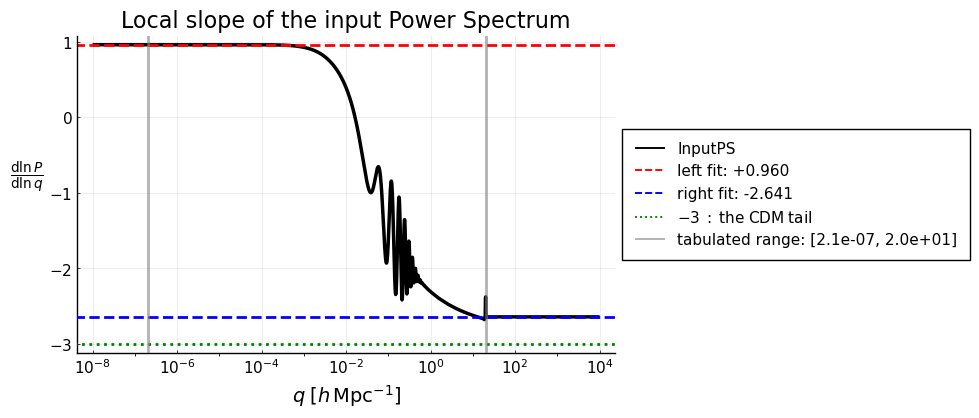

In [10]:
save_plot(plot_input_ps(), "input_ps.png")
save_plot(plot_local_slope(), "input_ps_slope.png")
save_data()

## END